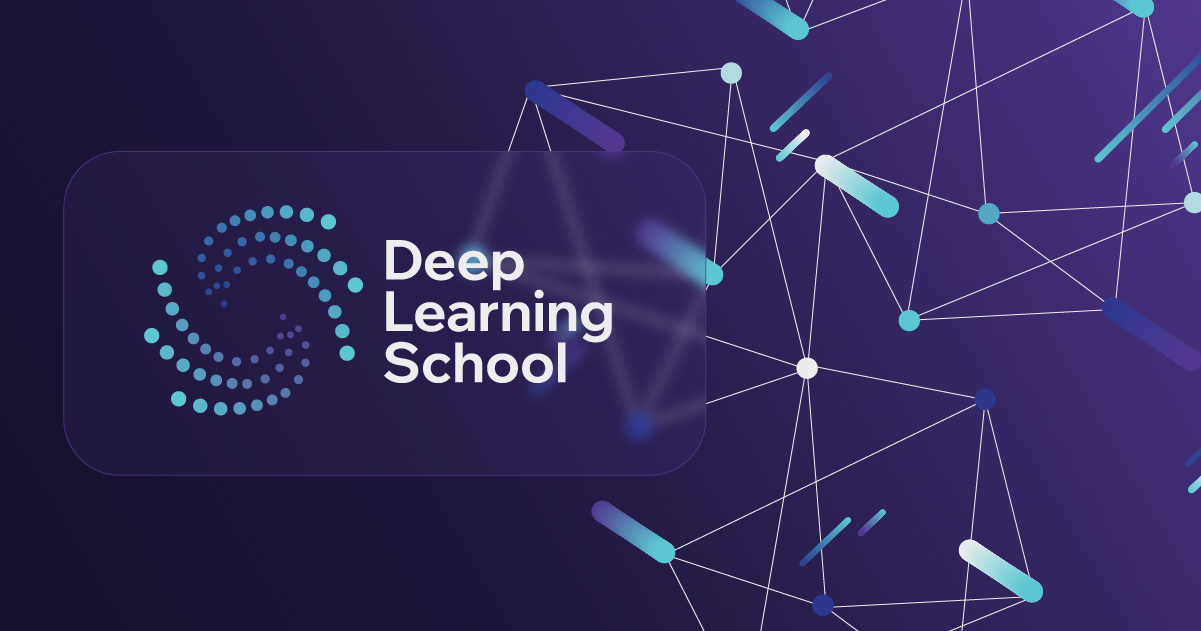

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Библиотека sklearn и классификация с помощью KNN</b></h1>

## Описание домашнего задания

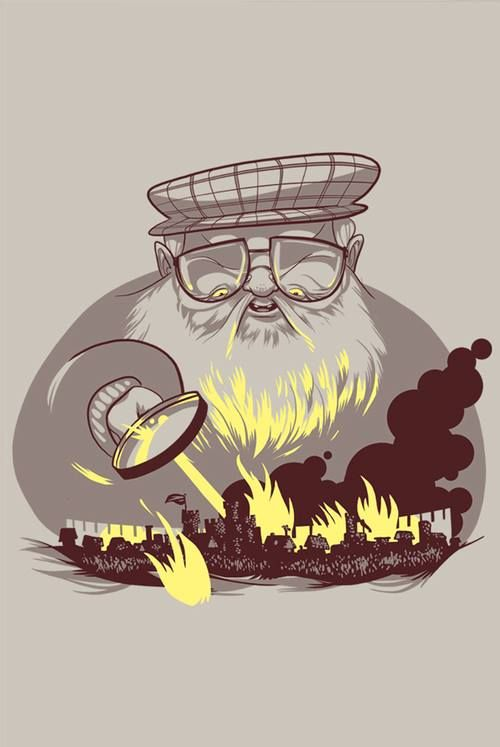

В данном задании вы будете работать с датасетом о персонажах из вселенной Игры Престолов [A Wiki of Ice and Fire](http://awoiaf.westeros.org/). Вам предстоит предсказать, кто из персонажей умрет, а кто останется вживых.



Описание данных:

* **name**: Имя персонажа

* **Title**: Социальный статус или знатность

* **House**: Дом, к которому принадлежит персонаж

* **Culture**: Социальная группа, к которой принадлежит персонаж

* **book1/2/3/4/5**: Появление персонажа в книге

* **Is noble**: Знатность персонажа, основанное на титуле

* **Age**: Отсчет времени: 305 AC

* **male**: Мужчина или женщина

* **dateOfBirth**: дата рождения

* **Spouse**: Имя супруги\а персонажа

* **Father**: Имя отца персонажа

* **Mother**: Имя матери персонажа

* **Heir**: Имя наследника персонажа

* **Is married**: Represents whether the character is married

* **Is spouse alive**: Represents whether character's spouse is alive

* **Is mother alive:** Жива ли мать персонажа

* **Is heir alive:** Жив ли наследник персонажа

* **Is father alive:** Указывает, жив ли отец персонажа

* **Number dead relations:** Количество умерших персонажей, с которыми персонаж связан

* **Popularity score:** Количество внутренних входящих и исходящих ссылок на страницу персонажей в вики http://awoiaf.westeros.org

Целевая переменная:
* **isAlive**: жив ли персонаж в книге

Оценивание:

Баллы считаются следующим образом:

1) $1.00 \geqslant score \geqslant 0.65$ --- 5 баллов

2) $0.65 > score \geqslant 0.50$ --- 4 балла

3) $0.50 > score \geqslant 0.45$ --- 3 балла

4) $0.45 > score \geqslant 0.40$ --- 2 балла

5) $0.40 > score \geqslant 0.35$ --- 1 балл

6) $0.35 > score$ --- 0 баллов

## Часть 1. Анализ и предобработка данных

Здесь вам необходимо сделать все шаги, которые обсуждались в первой части семинара.
* Предобработка данных
  * Обработка пропущенных данных
  * Создание новых признаков
  * Удаление ненужных столбцов
* Анализ данных
  * Анализ целевой переменной
  * Анализ признаков
  * Анализ влияния признаков на целевую переменную
* Подготовка данных для обучения модели

Загружаем датасет

In [ ]:
!gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3 # test dataset
!gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v # train dataset

Downloading...
From: https://drive.google.com/uc?id=1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3
To: /content/game_of_thrones_test.csv
100% 37.3k/37.3k [00:00<00:00, 15.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v
To: /content/game_of_thrones_train.csv
100% 138k/138k [00:00<00:00, 67.8MB/s]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Задание 1.1.** Импортируйте библиотеки pandas, matplotlib, seaborn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

**Задание 1.2.** Загрузите датасет в Pandas DataFrame при помощи функции `read_csv`. Вместо дефолтных наименований строк `0,1,...`, при помощи параметра `index_col`, сделайте значения колонки `S.No` наименованиями строк:

In [ ]:
data = pd.read_csv('/content/game_of_thrones_train.csv', index_col='S.No')
data

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,1.0,0.0,0.0,NaN,0,0,NaN,11,0.605351,0
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,...,NaN,NaN,NaN,1.0,1,1,97.0,1,0.896321,1
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,House Swyft,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.267559,1
4,Aemma Arryn,Queen,0,NaN,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,...,NaN,NaN,NaN,0.0,1,1,23.0,0,0.183946,0
5,Sylva Santagar,Greenstone,0,Dornish,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,...,NaN,NaN,NaN,1.0,1,1,29.0,0,0.043478,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,Marwyn,Archmaester,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.160535,1
1554,Masha Heddle,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,0,NaN,0,0.040134,0
1555,Matthos Seaworth,NaN,1,NaN,NaN,NaN,NaN,NaN,House Seaworth,NaN,...,NaN,NaN,NaN,NaN,0,0,NaN,0,0.076923,0


Посмотрите, какие типы данных представлены в нашем датасете

Знакомый нам метод describe() возвращает различную информацию для столбцов с числовыми типами данных, и с типами данных *object*

Давайте посмотрим на вывод для типа данных *object*. Для этого:
- сначала применим метод describe(). Укажем в качестве аргумента тип данных столбцов, статистику по которым мы хотим посмотреть (см. https://pandas.pydata.org/docs/reference/api/pandas.Series.map.html)
- для удобства восприятия транспонируем таблицу

In [ ]:
data.describe(include = 'object').T

,count,unique,top,freq
name,1557,1557,Melara Hetherspoon,1
title,717,195,Ser,306
culture,488,51,Northmen,94
mother,18,16,Rhaenyra Targaryen,2
father,22,19,Daemon Targaryen,2
heir,21,20,Jaehaerys Targaryen,2
house,1176,315,House Frey,89
spouse,200,186,Walder Frey,6


Теперь давайте посмотрим на столбцы с числовыми типами данных. Дополните код ниже. Для удобства восприятия мы транспонировали таблицу и ограничили вывод тремя столбцами - количество строк без NaN, максимальное и минимальное значение (о кастомизации вариантах вывода describe() вы можете почитать в документации по ссылке выше).


In [ ]:
data.describe(include = [np.number]).T[['count', 'min', 'max']]

,count,min,max
male,1557.0,0.0,1.0
dateOfBirth,279.0,-25.0,299.0
book1,1557.0,0.0,1.0
book2,1557.0,0.0,1.0
book3,1557.0,0.0,1.0
book4,1557.0,0.0,1.0
book5,1557.0,0.0,1.0
isAliveMother,18.0,0.0,1.0
isAliveFather,22.0,0.0,1.0
isAliveHeir,21.0,0.0,1.0


Так мы проверим, есть ли в данных неадекватнные значения.   Большинство числовых столбцов - это числа от 0 до 1. Отрицательные значения `dateOfBirth` не являются ошибкой. Значения age и `numDeadRelations` также выглядят адекватными. Можно переходить к дальнейшим шагам анализа (анонс - а в тестовых данных нас будет ждать сюрприз).

**Задание 1.3.** Предобработка (очистка) данных.

В нашем домашнем задании все пропуски в данных (missing values) уже закодированы как NaN. Проанализируйте, в каких колонках и как часто встречаются NaN значения. Далее вам надо будет принять решение, как их обрабатывать.

In [ ]:
data.isna().sum()

,0
name,0
title,840
male,0
culture,1069
dateOfBirth,1278
mother,1539
father,1535
heir,1536
house,381
spouse,1357


В этом задании удалять строки с NaN (dropna) мы не будем по следующим причинам:
- в обучающем датасете много признаков с большим количество пропусков. Если удалять все строки с NaN, то размер выборки сильно уменьшится. Мы потеряем много данных, которые можно было бы использовать для построения более точной модели.
- тестовом датасете также много признаков с NaN (вы можете в этом убедиться, если скачаете датасет и совершите с ним те же действия, что выше проделали с обучаюшим датасетом). Поэтому нам все-равно придется придумать способ кодировать NaN, чтобы модель делала прогнозы для всех персонажей из тестового датасета. Для этого нам потребуется сохранять, а не удалять данные в обучающем датасете.     



Как вы могли заметить, в наших данных очень много пропущенных значений, причём в некоторых случая пропущена **большая** часть значений. Поэтому заполнять по умолчанию медианой/средним/модой в данном случае - не самый лучший способ (однако, это довольно часто используемый метод заполнения, который может пригодиться вам в будущем)

Ниже мы посмотрим, как можно работать с признаками с большим количеством пропущенных значений.

**Задание 1.4.** Числовые признаки

У нас есть **признак popularity**. Постройте гистограмму распределения данного признака с количеством интервалов (bins), равным 50 (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.hist.html)

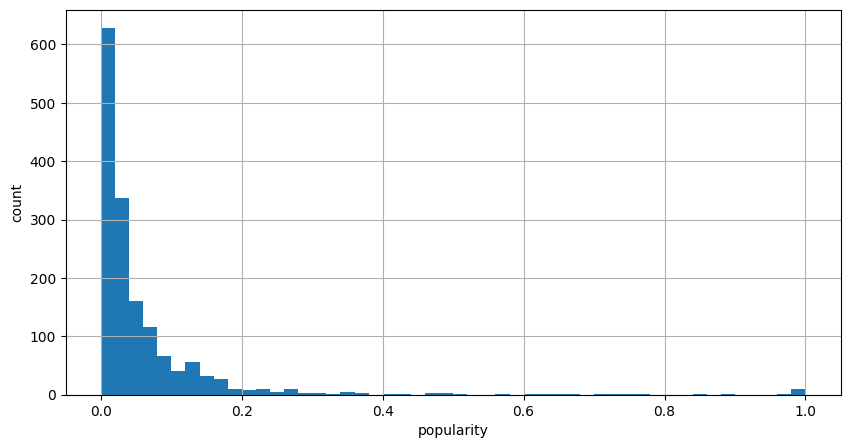

In [ ]:
plt.figure(figsize = (10, 5))

data['popularity'].hist(bins=50)
plt.ylabel('count')
plt.xlabel('popularity')

plt.show()

Распределение сильно несимметрично. Можно преобразовать данный признак, например, по формуле `np.log10(data["popularity"]*M+1)` (добавляем 1 ради логарифма, так как для некоторых персонажей `popularity==0`). В качестве M можно попробовать, например, M=100 или другое число.

При желании для `popularity` вы можете использовать свой способ шкалирования признаков с несимметричным распределением.


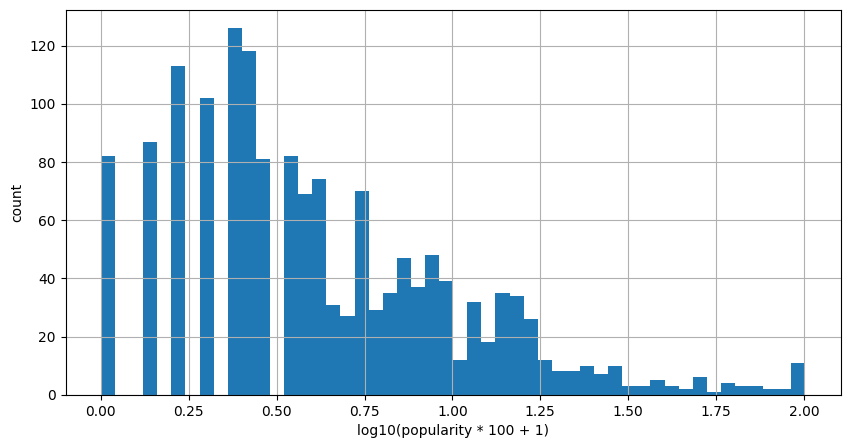

In [ ]:
data['popularity_log'] = np.log10(data['popularity'] * 100 + 1)

plt.figure(figsize=(10, 5))
data['popularity_log'].hist(bins=50)
plt.ylabel('count')
plt.xlabel('log10(popularity * 100 + 1)')
plt.show()

In [ ]:
data.drop('popularity_log', axis=1, inplace=True)

В качестве альтернативного подхода вы можете попробовать дискретизацию признака popularity на основе квантилей (quantile binning), используя функцию qcut() (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html). В этом случае вы преобразуете числовой признак popularity в категориальный, для которого в дальнейшем надо будет применить one-hot кодирование.

In [ ]:
num_quantiles = 4

data['popularity_quantile'] = pd.qcut(data['popularity'], q=num_quantiles, labels=False)

data[['popularity', 'popularity_quantile']]

,popularity,popularity_quantile
S.No,,
1,0.605351,3
2,0.896321,3
3,0.267559,3
4,0.183946,3
5,0.043478,2
...,...,...
1553,0.160535,3
1554,0.040134,2
1555,0.076923,3


Теперь давайте обработаем **признак numDeadRelations**.
Посмотрите на частотное распределение этого признака. Лишь для малого числа персонажей `numDeadRelations>0`.

Создайте признак `boolDeadRelations`. Давайте упростим признак `numDeadRelations`, и просто поделим людей на тех, у кого были хоть какие то отношения с мертвыми персонажами, т.е. `numDeadRelations > 0`, и те, у которых не было, т.е. `numDeadRelations = 0`.

In [ ]:
data['boolDeadRelations'] = (data['numDeadRelations'] > 0).astype(int)

In [ ]:
data[['boolDeadRelations', 'numDeadRelations']]

,boolDeadRelations,numDeadRelations
S.No,,
1,1,11
2,1,1
3,0,0
4,0,0
5,0,0
...,...,...
1553,0,0
1554,0,0
1555,0,0


Наконец, давайте посмотрим на **признак age**. В нем очень много пропущенных значений. Для того, чтобы использовать в модели информацию о возрасте персонажа, мы создадим два новых признака: `age_value` и `age_no_data`

- Там где возраст указан, age_value принимает значение `age`, а `age_no_data` - значение 0.
- Там где возраст не указан, `age_value` принимает значение 0, а `age_no_data` - значение 1.  

Фактически, в переменной `age` мы заменяем NaN на 0, но одновременно добавляем в модель еще один бинарный признак `age_no_data`, несущий информацию о том, у каких персонажей не был указан возраст:        

In [ ]:
data['age_value'] = [x if not np.isnan(x) else 0 for x in data['age']]
data['age_no_data'] = [1 if np.isnan(x) else 0 for x in data['age']]

In [ ]:
data[['age', 'age_value', 'age_no_data']]

,age,age_value,age_no_data
S.No,,,
1,NaN,0.0,1
2,97.0,97.0,0
3,NaN,0.0,1
4,23.0,23.0,0
5,29.0,29.0,0
...,...,...,...
1553,NaN,0.0,1
1554,NaN,0.0,1
1555,NaN,0.0,1


Этот способ чем-то похож на работу с категориальной переменными с пропущенными значениями, когда мы добавляем еще одну категорию no_data и заменяем NaN на значение этой категории.

Если вы заходите похожим образом образом обработать признак `dateOfBirth`, **обратите внимание**, что у одних и тех же персонажей не указан и возраст, и год рождения.
То есть созданные признаки `age_no_data` и `dateOfBirth_no_data` будут полностью совпадать, и в модель надо будет включать только один из признаков: или `age_no_data`, или `dateOfBirth_no_data`.

In [ ]:
data['dateOfBirth_value'] = data['dateOfBirth'].fillna(0)

In [ ]:
data.isna().sum()

,0
name,0
title,840
male,0
culture,1069
dateOfBirth,1278
mother,1539
father,1535
heir,1536
house,381
spouse,1357


**Задание 1.5.** Категориальные признаки с большим количеством категорий

**Признак culture** содержит информацию о принадлежности к одному из народов во вселенной Игры Престолов.

Давайте посмотрим, какие значения принимает данный признак. По умолчанию метод `value_counts()` игнорирует пропуски в данных, поэтому используем этот метод с параметром **dropna** со значением **False** (см. https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.value_counts.html)

In [ ]:
data['culture'].value_counts(dropna=False)

,count
culture,
NaN,1069
Northmen,94
Ironborn,91
Free Folk,45
Braavosi,39
Valyrian,28
Ghiscari,17
Dornish,17
Dothraki,17


Из полученного частотного распределения видно, что для большого числа персонажей значения данного признака не указаны. Также есть много редких значений признака, которые в выборке повторяются один или несколько раз. Причина отчасти в том, что один и тот же народ упоминается в нашем датасете под разными названиями.

Данную проблему мы попытаемся решить, сгруппировав народы в более крупные категории. Так мы одновременно решим проблему того, что один и тот же народ назван в выборке разными способами.

Предоженный вариант группировки имеет определенную логику. Выделяются следующие группы:
- старые нации, которые уже не сущевали как отдельные народы на момент повествования основной линии повествования романов, но отдельные потомки могли еще быть живы
- народы, проживающие в королевствах континента Весторос (для каждого королевства - своя группа)
- народы континента Эссос
- прочие народы

In [ ]:
cultures_grouped = {
    'Old Nations': ['valyrian', 'first men', 'andal', 'andals', 'rhoynar'],
    'the North': ['northmen', 'northern mountain clans', 'crannogmen'],
    'the Iron Islands': ['ironborn', 'ironborn', 'ironmen'],
    'the Mountain and the Vale': ['valemen', 'vale', 'vale mountain clans',
                              'sistermen'],
    'the Isles and Rivers': ['riverlands', 'rivermen'],
    'the Rock': ['westerman', 'westermen', 'westerlands'],
    'the Stormlands': ['stormlander', 'stormlands'],
    'the Reach': ['reach', 'reachmen', 'the reach'],
    'Dorne': ['dornish', 'dornishmen', 'dorne'],
    'Essos Nations': ['astapor', 'astapori', 'braavosi', 'braavos', 'tyroshi', 'lysene', 'lyseni',
                      'myrish', 'pentoshi', 'qartheen', 'qarth', 'dothraki',
                      'lhazarene', 'lhazareen','meereen', 'meereenese',
                      'norvoshi', 'qohor', 'summer isles', 'summer islands',
                      'summer islander', 'asshai', "asshai'i", 'norvos', 'ghiscari',
                      'ghiscaricari'],
    'Other Nations': ['ibbenese', 'westeros', 'free folk', 'wildling', 'wildlings', 'naathi']}

**Обратите внимание, что некоторые варианты названий народов встречаются только в тестовых данных, и не встречаются в обучающих данных.** Такая ситуация нередко случается на практике. Поэтому, после обработки обучающих данных и обучения модели важно задать для модели правило, как она должна обрабатывать "незнакомые" категории в категориальных признаках. Например, можно относить объекты с "незнакомой" категорией к некоторой существующей категории или указать формулу расчета для "незнакомой" категории.     

Предложенный вам словарь `cultures_grouped` составлен по всем значениям признака `culture`, встречающимся в тренировочном либо в тестовом датасете. Здесь важно, что все укрупненные категории (ключи/keys словаря `cultures_grouped`) представлены в обоих датасетах, а уникальные для тестового датасета названия народов - это отдельные названия народов внутри укрупненных категорий (значения/values словаря). Поэтому, когда вы будете работать с тестовыми - просто применяйте этот словарь без указания правила обработки "незнакомых" категорий.

Давайте приступим к кодировке значений признака culture.
Для этого сначала инвертируем словарь *cultures_grouped*

In [ ]:
#Довольно просто инвертировать словарь, где ключу соответствует одно значение
#В нашем случае ключу соответствует список значений.
#Ниже показан пример, как можно инвертировать такой словарь

d = {'A': ['a1', 'a2', 'a3'],
     'B': ['b1', 'b2', 'b3', 'b4']}

d_inverted = {}
for k in d.keys():
  for v in d[k]:
      d_inverted.update({v:k})

d_inverted

{'a1': 'A', 'a2': 'A', 'a3': 'A', 'b1': 'B', 'b2': 'B', 'b3': 'B', 'b4': 'B'}

In [ ]:
# По аналогии с примером выше инвертируйте словарь cultures_grouped
cultures_grouped_inverted = {}
for k in cultures_grouped.keys():
  for v in cultures_grouped[k]:
    cultures_grouped_inverted.update({v:k})

cultures_grouped_inverted

{'valyrian': 'Old Nations',
 'first men': 'Old Nations',
 'andal': 'Old Nations',
 'andals': 'Old Nations',
 'rhoynar': 'Old Nations',
 'northmen': 'the North',
 'northern mountain clans': 'the North',
 'crannogmen': 'the North',
 'ironborn': 'the Iron Islands',
 'ironmen': 'the Iron Islands',
 'valemen': 'the Mountain and the Vale',
 'vale': 'the Mountain and the Vale',
 'vale mountain clans': 'the Mountain and the Vale',
 'sistermen': 'the Mountain and the Vale',
 'riverlands': 'the Isles and Rivers',
 'rivermen': 'the Isles and Rivers',
 'westerman': 'the Rock',
 'westermen': 'the Rock',
 'westerlands': 'the Rock',
 'stormlander': 'the Stormlands',
 'stormlands': 'the Stormlands',
 'reach': 'the Reach',
 'reachmen': 'the Reach',
 'the reach': 'the Reach',
 'dornish': 'Dorne',
 'dornishmen': 'Dorne',
 'dorne': 'Dorne',
 'astapor': 'Essos Nations',
 'astapori': 'Essos Nations',
 'braavosi': 'Essos Nations',
 'braavos': 'Essos Nations',
 'tyroshi': 'Essos Nations',
 'lysene': 'Essos Na

Теперь создадим новый столбец с укрупненными значениями culture.

Для этого будем использовать метод `map()` с инвертированным словарем в качестве аргумента (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.map.html)

Обратите внимание, что в словаре названия народов указаны в нижнем регистре. А в датасете используется как нижний, так и верхний регистр. Поэтому перед применением метода `map()` переведем значения столбца culture в нижний регистр при помощи метода `str.lower()` (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.str.lower.html).

In [ ]:
data['culture_grouped'] = data['culture'].str.lower().map(cultures_grouped_inverted)

Осталось заменить все NaN в созданном столбце на категорию `culture_no_data`:

---



In [ ]:
data['culture_grouped'] = data['culture_grouped'].fillna('culture_no_data')

Распределение сгруппированной переменной выглядит гораздо лучше. Но по прежнему есть несколько слабо представленых групп.

Дальнейшую работу с этим признаком проводите на свое усмотрение для повышения качества прогноза модели. Например, можно объединить несколько слабо представленных категорий в одну или применить другой подход.

<Axes: >

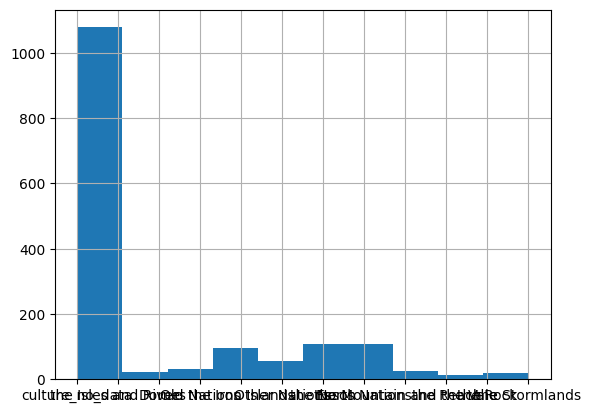

In [ ]:
data['culture_grouped'].hist()

In [ ]:
freq = data['culture_grouped'].value_counts()

categories_to_keep = freq[freq >= 30].index.tolist()

data['culture_final'] = data['culture_grouped'].apply(
    lambda x: x if x in categories_to_keep else 'other_culture'
)

In [ ]:
print(data['culture_final'].value_counts())
print(data['culture_final'].value_counts(normalize=True) * 100)

culture_final
culture_no_data     1069
Essos Nations        109
the North            108
the Iron Islands      95
other_culture         87
Other Nations         57
Old Nations           32
Name: count, dtype: int64
culture_final
culture_no_data     68.657675
Essos Nations        7.000642
the North            6.936416
the Iron Islands     6.101477
other_culture        5.587669
Other Nations        3.660886
Old Nations          2.055234
Name: proportion, dtype: float64


In [ ]:
data.drop('culture_grouped', axis=1, inplace=True)

**Задание 1.6.** Категориальные признаки в линейных моделях

Для включения категориальных признаков в линейную модель их нужно преобразовать в числовые признаки.

Если признак принимает одно из двух возможных значений (например, персонаж "появляется" или "не появляется" в 1-й книге), он напрямую кодируется в бинарный признак ("появляется" -> 1, "не появляется" -> 0). Если признак принимает больше двух значений, его можно преобразовать в несколько бинарных при помощи one-hot преобразования. В некоторых случаях бывает полезно объединить некоторые категории, как мы это поступили с признаком *culture*.

Порядковых признаков у нас в задаче нет, поэтому рассматривать их здесь мы не будем.

Для того, чтобы найти все порядковые признаки, посмотрим на количество уникальных значений, которые встречаются в столбцах. Для столбцов с типом object количество уникальных значений мы выводили  при помощи метода `describe()` в задании 1.2.

Чтобы посмотреть количество уникальных значений для всех столбцов, можно воспользоваться методом nunique() (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.nunique.html)

In [ ]:
# Количество уникальнх значений в каждом столбце
data.nunique()

,0
name,1557
title,195
male,2
culture,51
dateOfBirth,105
mother,16
father,19
heir,20
house,315
spouse,186


In [ ]:
# Для числовых столбцов можно вывести в одну таблицу более детальную статистику, объединив выводы describe() и nunique()
# Код ниже требуется дополнить по аналогии с заданием 1.2.
data.describe(include = [np.number]).T[['count', 'min', 'max']].assign(N_unique_values = data.nunique())

,count,min,max,N_unique_values
male,1557.0,0.0,1.0,2
dateOfBirth,279.0,-25.0,299.0,105
book1,1557.0,0.0,1.0,2
book2,1557.0,0.0,1.0,2
book3,1557.0,0.0,1.0,2
book4,1557.0,0.0,1.0,2
book5,1557.0,0.0,1.0,2
isAliveMother,18.0,0.0,1.0,2
isAliveFather,22.0,0.0,1.0,2
isAliveHeir,21.0,0.0,1.0,2


Посмотрев на количество уникальных значений мы можем выделить категориальные признаки. Например, `popularity` принимает значения от 0 до 1, но это непрерывный числовой признак. Остальные признаки со значениями от 0 до 1 - принимают только два значения, то есть являются бинарными.

Бинарные признаки без NaN полностью готовы для включения в модель. Некоторые бинарные признаки содержат пропуски, поэтому, если вы захотите включить их в модель, их потребуется обработать.

Для бинарных признаков их связь с зависимой переменной можно прикинуть по таблице корреляций. Для категориальных признаков с количеством значений больше двух (или с двумя значениями и NaN) можно сделать one-hot преобразования и посчитать корреряцию зависимой переменной с набором сгенерированных бинарных признаков.
В качестве альтернативного подхода можно использовать сравнение средних значений зависимой переменной для разных категорий исследуемого признака. Чем сильнее различаются средние значения целевой переменной между категориями, тем вероятнее, что данный признак связан с зависимой переменной.

In [ ]:
# попробуйте провести сравнение средних зависимой пременной isAlive для признака isAliveSpouse
# одним из приведенных ниже способов:

data.groupby('isAliveSpouse', dropna = False)['isAlive'].mean()
pd.pivot_table(data = data, values = 'isAlive', index = 'isAliveSpouse', aggfunc=['mean', 'count'], dropna=False)

,mean,count
,isAlive,isAlive
isAliveSpouse,,
0.0,0.619048,42
1.0,0.753165,158
NaN,0.786293,1357


In [ ]:
data.groupby('isAliveHeir', dropna = False)['isAlive'].mean()
pd.pivot_table(data = data, values = 'isAlive', index = 'isAliveHeir', aggfunc=['mean', 'count'], dropna=False)

,mean,count
,isAlive,isAlive
isAliveHeir,,
0.0,0.000000,7
1.0,0.357143,14
NaN,0.785807,1536


In [ ]:
data.groupby('isAliveFather', dropna = False)['isAlive'].mean()
pd.pivot_table(data = data, values = 'isAlive', index = 'isAliveFather', aggfunc=['mean', 'count'], dropna=False)

,mean,count
,isAlive,isAlive
isAliveFather,,
0.0,0.235294,17
1.0,0.400000,5
NaN,0.785668,1535


In [ ]:
data.groupby('isAliveMother', dropna = False)['isAlive'].mean()
pd.pivot_table(data = data, values = 'isAlive', index = 'isAliveMother', aggfunc=['mean', 'count'], dropna=False)

,mean,count
,isAlive,isAlive
isAliveMother,,
0.0,0.166667,6
1.0,0.166667,12
NaN,0.785575,1539


In [ ]:
data['has_spouse_info'] = data['isAliveSpouse'].notna().astype(int)
data['has_heir_info'] = data['isAliveHeir'].notna().astype(int)
data['has_mother_info'] = data['isAliveMother'].notna().astype(int)
data['has_father_info'] = data['isAliveFather'].notna().astype(int)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1557 entries, 1 to 1557
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 1557 non-null   object 
 1   title                717 non-null    object 
 2   male                 1557 non-null   int64  
 3   culture              488 non-null    object 
 4   dateOfBirth          279 non-null    float64
 5   mother               18 non-null     object 
 6   father               22 non-null     object 
 7   heir                 21 non-null     object 
 8   house                1176 non-null   object 
 9   spouse               200 non-null    object 
 10  book1                1557 non-null   int64  
 11  book2                1557 non-null   int64  
 12  book3                1557 non-null   int64  
 13  book4                1557 non-null   int64  
 14  book5                1557 non-null   int64  
 15  isAliveMother        18 non-null     float6

**Задание 1.7.** Проанализируйте признаки.
  * Обработайте категориальные признаки и переведите их в числа. Можете выбрать любой кодировщик. Не забудьте, что потом аналогичным образом вам надо будет преобразовывать тестовый датасет, используя тот же алгоритм кодирования признаков.
  * Проанализируйте количественные признаки. Есть ли корреляция между признаками?

In [ ]:
data.drop(['isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse'], axis=1, inplace=True)

In [ ]:
data.drop(['name', 'culture', 'mother', 'father', 'heir', 'spouse', 'age', 'numDeadRelations', 'popularity'], axis=1, inplace=True)

In [ ]:
data.drop('dateOfBirth', axis=1, inplace=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1557 entries, 1 to 1557
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   title                717 non-null    object 
 1   male                 1557 non-null   int64  
 2   house                1176 non-null   object 
 3   book1                1557 non-null   int64  
 4   book2                1557 non-null   int64  
 5   book3                1557 non-null   int64  
 6   book4                1557 non-null   int64  
 7   book5                1557 non-null   int64  
 8   isMarried            1557 non-null   int64  
 9   isNoble              1557 non-null   int64  
 10  isAlive              1557 non-null   int64  
 11  popularity_quantile  1557 non-null   int64  
 12  boolDeadRelations    1557 non-null   int64  
 13  age_value            1557 non-null   float64
 14  age_no_data          1557 non-null   int64  
 15  dateOfBirth_value    1557 non-null   float6

In [ ]:
data['title'].value_counts()

,count
title,
Ser,306
Maester,29
Archmaester,21
Lord,19
Septon,16
...,...
Lord of Hellholt,1
Red Flower Vale,1
Lord of Harrenhal,1


In [ ]:
data['title'].unique()

array([nan, 'Lord of the Crossing', 'Ser', 'Queen', 'Greenstone',
       'Hand of the King', 'Archmaester', 'Maester', 'Khal', 'red hand',
       'Castellan', 'Seven Kingdoms', 'PrincessQueen',
       'Lord of the Iron Islands', 'Lord', 'Brother', 'Lord of Coldmoat',
       'Prince of Dragonstone', 'Lady', 'PrincessSepta', 'Princess',
       'Septa', 'Grand Maester', 'Septon', 'King', 'Seneschal',
       'Bloodrider', 'Stokeworth', 'Prince', 'LadyQueenDowager Queen',
       'Lord of the Tides', 'Lord of Dragonstone', 'Goodman', 'Wisdom',
       'King in the North', 'Winterfell', 'Steward', 'Eyrie',
       'Casterly Rock', 'Cupbearer', 'Hornwood',
       'Lord Steward of the Iron Islands', 'Blue Grace', 'Red Priest',
       'Khalakka', 'Good Master', 'QueenBlack Bride', 'Last Hearth',
       'Lord Paramount of the Mander', 'Seagard', 'Goodwife', 'Uplands',
       'BrotherProctor', 'Coldmoat', 'Ashford', 'Wind Witch', 'LadyQueen',
       'Broad Arch', 'Brightwater', 'Lady Marya', 'Blackc

In [ ]:
def group_title_simple(title):
  if pd.isna(title):
    return 'no_title'

  title_lower = title.lower()
  if any(word in title_lower for word in ['king', 'queen', 'prince', 'princess', 'khal', 'khalakka']):
    return 'royal'

  if any(word in title_lower for word in ['lord', 'lady']):
    return 'lord'

  if any(word in title_lower for word in ['maester', 'archmaester', 'grand maester', 'master']):
    return 'maester'

  if any(word in title_lower for word in ['ser', 'knight']):
    return 'ser'

  return 'other'

data['title_group'] = data['title'].apply(group_title_simple)

In [ ]:
data['title_group'].value_counts()

,count
title_group,
no_title,840
ser,310
other,200
lord,78
maester,66
royal,63


In [ ]:
data.drop('title', axis=1, inplace=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1557 entries, 1 to 1557
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   male                 1557 non-null   int64  
 1   house                1176 non-null   object 
 2   book1                1557 non-null   int64  
 3   book2                1557 non-null   int64  
 4   book3                1557 non-null   int64  
 5   book4                1557 non-null   int64  
 6   book5                1557 non-null   int64  
 7   isMarried            1557 non-null   int64  
 8   isNoble              1557 non-null   int64  
 9   isAlive              1557 non-null   int64  
 10  popularity_quantile  1557 non-null   int64  
 11  boolDeadRelations    1557 non-null   int64  
 12  age_value            1557 non-null   float64
 13  age_no_data          1557 non-null   int64  
 14  dateOfBirth_value    1557 non-null   float64
 15  culture_final        1557 non-null   object

In [ ]:
data['house'].unique()

array([nan, 'House Frey', 'House Swyft', 'House Arryn', 'House Santagar',
       'House Targaryen', 'House Osgrey', "Night's Watch", 'House Humble',
       'House Wylde', 'House Wode', 'House Fell',
       'Brotherhood Without Banners', 'House Webber', 'House Greyjoy',
       'House Stark', 'House Waynwood', 'House Dayne', 'House Manderly',
       'House Farwynd of the Lonely Light', 'Happy Port',
       'House of Loraq', 'Kingswood Brotherhood', 'House Botley',
       'Burned Men', 'House Velaryon', 'House Tallhart', 'House Tyrell',
       'House Blackwood', 'House Blackfyre', 'wildling',
       'Kingdom of the Three Daughters',
       'House Royce of the Gates of the Moon', 'House Nayland',
       "House Vance of Wayfarer's Rest", 'House Rowan', 'House Farrow',
       'House Lonmouth', 'House Reyne', 'House Ashford', 'House Brax',
       'House Paege', 'House Hollard', 'House Tarth', 'House Ryswell',
       'House Lannister', 'House Crakehall', 'House Darklyn',
       'House Westerli

In [ ]:
data['has_house'] = data['house'].notna().astype(int)
data.drop('house', axis=1, inplace=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1557 entries, 1 to 1557
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   male                 1557 non-null   int64  
 1   book1                1557 non-null   int64  
 2   book2                1557 non-null   int64  
 3   book3                1557 non-null   int64  
 4   book4                1557 non-null   int64  
 5   book5                1557 non-null   int64  
 6   isMarried            1557 non-null   int64  
 7   isNoble              1557 non-null   int64  
 8   isAlive              1557 non-null   int64  
 9   popularity_quantile  1557 non-null   int64  
 10  boolDeadRelations    1557 non-null   int64  
 11  age_value            1557 non-null   float64
 12  age_no_data          1557 non-null   int64  
 13  dateOfBirth_value    1557 non-null   float64
 14  culture_final        1557 non-null   object 
 15  has_spouse_info      1557 non-null   int64 

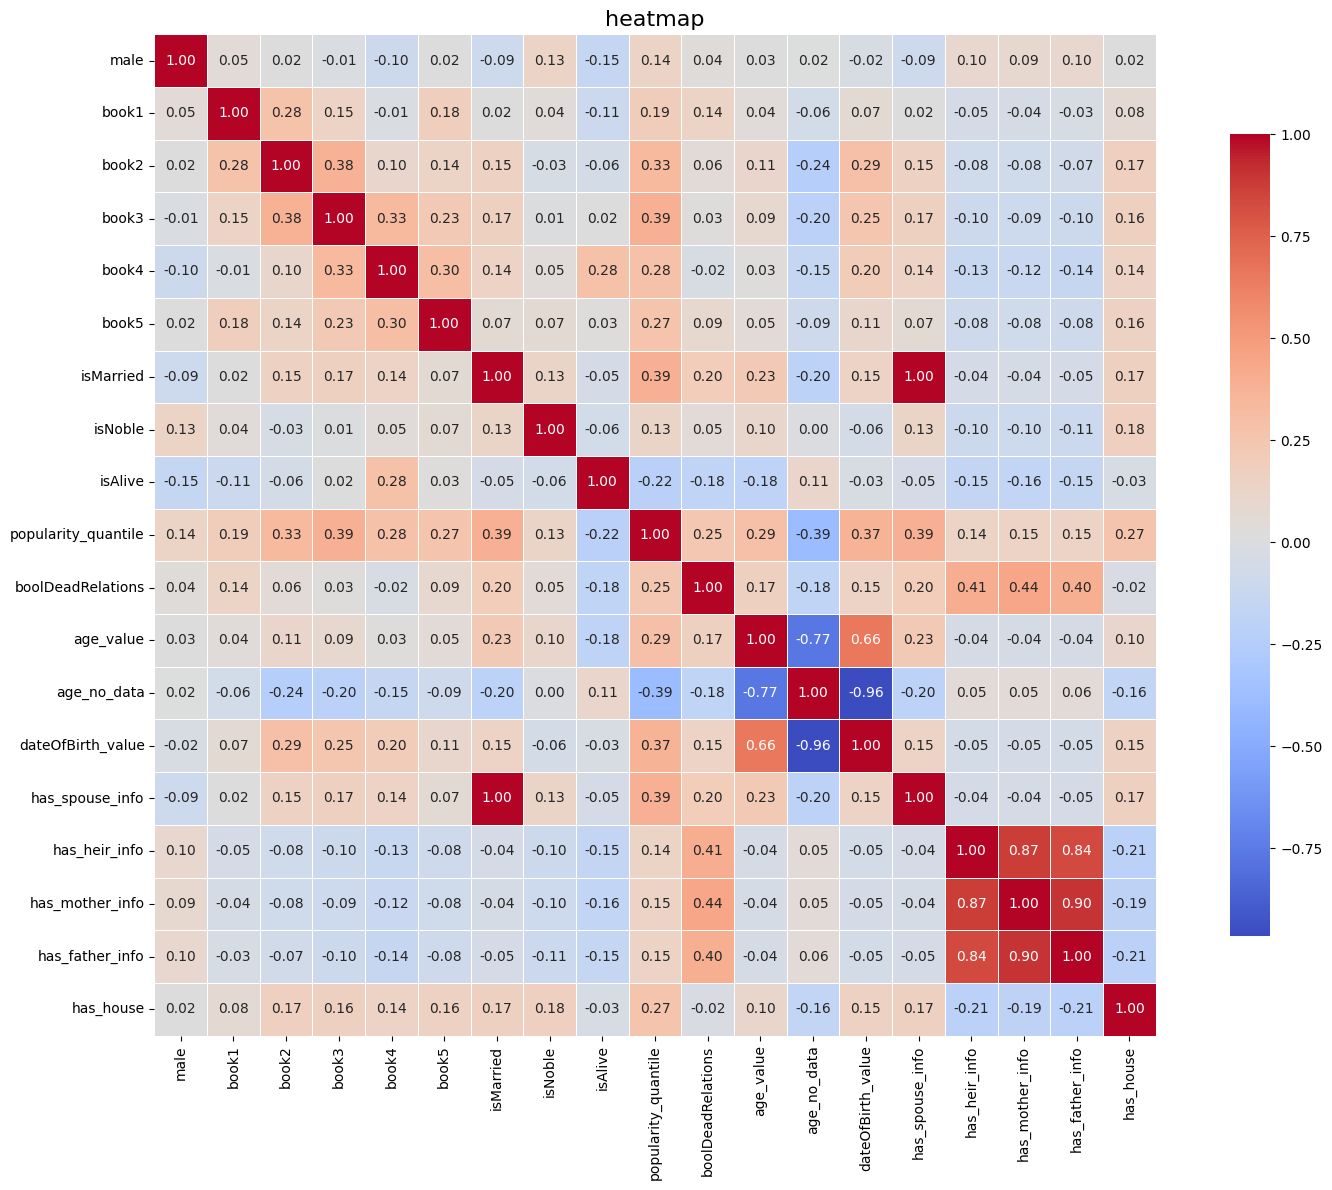

In [ ]:
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
corr_matrix = data[numeric_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('heatmap', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
data.drop('isMarried', axis=1, inplace=True)

In [ ]:
data['has_any_relative_info'] = (
    data['has_mother_info'] |
    data['has_father_info'] |
    data['has_heir_info']
).astype(int)

data.drop(['has_mother_info', 'has_father_info', 'has_heir_info'], axis=1, inplace=True)

In [ ]:
categorical_columns = [column for column in data.columns if data[column].dtype == 'O']
categorical_columns

['culture_final', 'title_group']

In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='if_binary', sparse_output=False)
ohe.fit(data[categorical_columns])
new_category_columns = ohe.transform(data[categorical_columns])

In [ ]:
new_train_columns = pd.DataFrame(new_category_columns,
                                 columns=ohe.get_feature_names_out(),
                                 index=data.index)
train_data = data.drop(columns=categorical_columns)
data = pd.concat([train_data, new_train_columns], axis=1)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1557 entries, 1 to 1557
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   male                            1557 non-null   int64  
 1   book1                           1557 non-null   int64  
 2   book2                           1557 non-null   int64  
 3   book3                           1557 non-null   int64  
 4   book4                           1557 non-null   int64  
 5   book5                           1557 non-null   int64  
 6   isNoble                         1557 non-null   int64  
 7   isAlive                         1557 non-null   int64  
 8   popularity_quantile             1557 non-null   int64  
 9   boolDeadRelations               1557 non-null   int64  
 10  age_value                       1557 non-null   float64
 11  age_no_data                     1557 non-null   int64  
 12  dateOfBirth_value               1557 no

**Задание 1.8.** Проанализируйте влияние признаков на целевую переменную.

---



Корреляция с isAlive:
 isAlive                           1.000000
book4                             0.284014
age_no_data                       0.113629
culture_final_the Iron Islands    0.064933
title_group_no_title              0.056242
culture_final_Essos Nations       0.037287
book5                             0.032531
title_group_maester               0.020143
book3                             0.018427
culture_final_culture_no_data     0.009564
culture_final_other_culture       0.008601
title_group_other                 0.006082
culture_final_the North          -0.000422
title_group_ser                  -0.001201
dateOfBirth_value                -0.027024
has_house                        -0.033892
culture_final_Other Nations      -0.035985
title_group_lord                 -0.040527
has_spouse_info                  -0.049381
book2                            -0.055998
isNoble                          -0.060572
book1                            -0.112468
title_group_royal              

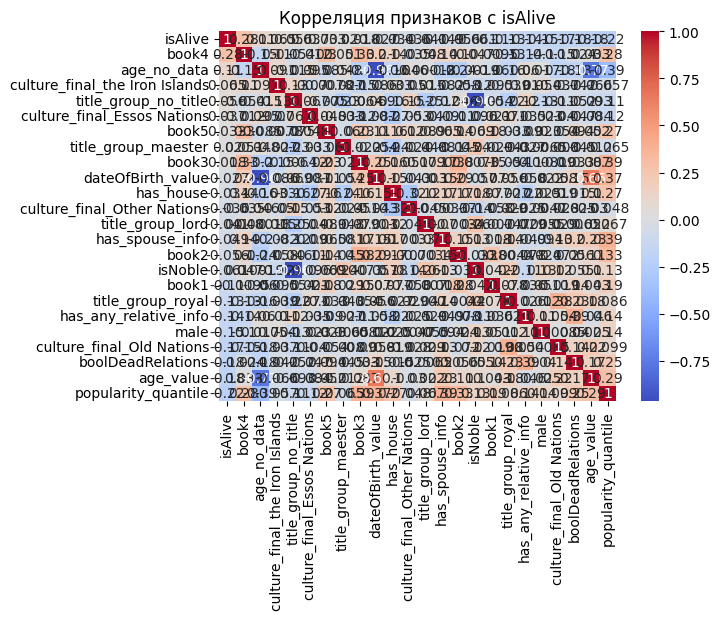

In [ ]:
correlations = data.corr()['isAlive'].sort_values(ascending=False)
print("Корреляция с isAlive:\n", correlations)

top_features = correlations[abs(correlations) > 0.01].index
sns.heatmap(data[top_features].corr(), annot=True, cmap='coolwarm')
plt.title('Корреляция признаков с isAlive')
plt.show()

**Задание 1.9.** Создайте переменные `X`, которая будет хранить только значения признаков, которые вы отобрали для включения в модель, и `y`, которая будет хранить только значения целевой переменной.

In [ ]:
correlations = data.corr()['isAlive'].drop('isAlive')

selected_features = correlations[abs(correlations) > 0.001].index.tolist()

X = data[selected_features]
y = data['isAlive']

**Задание 1.10.** Разделите датасет обучащую и валидационные части (train и val) при помощи функции `train_test_split` (https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# не забудьте в функции train_test_split задать параметр random_state,
# чтобы обеспечить повторяемость разбиения выборки на train и validation части.
# Это позволит сравнивать метрики моделей с различными методами подготовки признаков
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1245 entries, 783 to 1127
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   male                            1245 non-null   int64  
 1   book1                           1245 non-null   int64  
 2   book2                           1245 non-null   int64  
 3   book3                           1245 non-null   int64  
 4   book4                           1245 non-null   int64  
 5   book5                           1245 non-null   int64  
 6   isNoble                         1245 non-null   int64  
 7   popularity_quantile             1245 non-null   int64  
 8   boolDeadRelations               1245 non-null   int64  
 9   age_value                       1245 non-null   float64
 10  age_no_data                     1245 non-null   int64  
 11  dateOfBirth_value               1245 non-null   float64
 12  has_spouse_info                 1245 

In [ ]:
y_train

,isAlive
S.No,
783,1
1237,1
773,1
1301,0
384,1
...,...
1131,1
1295,1
861,0


## Часть 2. Обучение моделей

В данной части домашнего задания, мы хотим научиться обучать модели для задачи классификации на наших данных.

**Задание 2.1.**


Вы можете работать с одной из предложенных моделей из библиотеки `sklearn`
* LogisticRegression
* RandomForestClassifier
* AdaBoostClassifier
* GaussianProcessClassifier
* GaussianNB
* KNeighborsClassifier
* SVC
* DecisionTreeClassifier


Однако в этом домашнем задании мы предлагаем выбрать и поработать с моделью `LogisticRegression`.

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

Импортируйте остальные модели из библиотеки `sklearn`. Чтобы понять как это сделать, воспользуйтесь официальный документацией `sklearn` $→$ [тык](https://scikit-learn.org/dev/user_guide.html). По ключевому названию модели, вы сможете найти необходимую информацию о том, как можно импортировать модель из библиотеки.

**Задание 2.2.** Обучите модель и сделайте предсказание на тестовой выборке

В качестве примера, обучим модель `LogisticRegression` и сделаем на ней предсказания на тестовой выборке.

In [ ]:
print("Пропуски в X_train:", X_train.isna().sum().sum())
print("Пропуски в X_val:", X_val.isna().sum().sum())

Пропуски в X_train: 0
Пропуски в X_val: 0


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [ ]:
model = LogisticRegression(C = 20, solver='liblinear', penalty='l1', random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(C=20, max_iter=1000, penalty='l1', random_state=42,
                   solver='liblinear')

In [ ]:
# from sklearn.model_selection import GridSearchCV
# from sklearn.ensemble import RandomForestClassifier

# X_train_scaled = X_train
# X_val_scaled = X_val
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [None, 10, 20, 30],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': ['sqrt', 'log2']
# }
# rf = RandomForestClassifier(random_state=42, n_jobs=-1)
# grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
# grid_search.fit(X_train, y_train)

# print("Лучшие параметры:", grid_search.best_params_)
# print("Accuracy на кросс-валидации:", grid_search.best_score_)
# print("Accuracy на валидации:", grid_search.score(X_val, y_val))


In [ ]:
# from sklearn.ensemble import RandomForestClassifier

# # Масштабирование можно убрать, так как для RandomForest оно не нужно
# # scaler = StandardScaler()
# # X_train_scaled = scaler.fit_transform(X_train)
# # X_val_scaled = scaler.transform(X_val)

# X_train_scaled = X_train
# X_val_scaled = X_val
# # Обучаем RandomForestClassifier
# model = RandomForestClassifier(
#     n_estimators=100,      # количество деревьев
#     max_depth=10,           # максимальная глубина (можно не ограничивать, но для борьбы с переобучением)
#     random_state=42,        # для воспроизводимости
# )
# model.fit(X_train, y_train)  # используем исходные признаки (без масштабирования)


In [ ]:
# X_train_scaled = X_train
# X_val_scaled = X_val

# base_tree = DecisionTreeClassifier(max_depth=1, random_state=42)
# model = AdaBoostClassifier(
#     estimator=base_tree,
#     n_estimators=100,
#     learning_rate=1.0,
# )

# model.fit(X_train, y_train)

# y_pred = model.predict(X_val)

# accuracy = accuracy_score(y_val, y_pred)
# print(f"AdaBoost Accuracy: {accuracy:.4f}")

## Часть 3. Оцените качество моделей

Вам необходимо познакомиться с метриками задачи классификации из sklearn. Оцените все модели и выберите лучшую по метрике качества Accuracy.

С метриками классификации вы можете ознакомиться в [Yandex ML Book](https://education.yandex.ru/handbook/ml/article/metriki-klassifikacii-i-regressii).

Для простоты в данном домашнем задании мы будем работать с самой базовой метрикой для задачи классификации - accuracy.

**Задание 3.1.** Вам необходимо посчитать метрику для всех моделей и выбрать лучшую модель.

Сначала импортируем необходимую функцию из библиотеки sklearn для подсчета accuracy.

In [ ]:
from sklearn.metrics import accuracy_score

В качестве примера, посчитаем метрику accuracy для модели `LogisticRegression`:

In [ ]:
# Шаг 3. Предсказание на тестовых данных
y_pred = model.predict(X_val_scaled)

# Шаг 4. Оценка предсказания по метрике accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_val, y_pred)
print("Accuracy : %.4f" % accuracy) # 0.8237

Accuracy : 0.8333


Возможно, вы решите вернуться на несколько шагов и попробовать другие варианты преобразования и подбора признаков в модель. **Выберите** лучшую модель.

### Тестовый датасет

В самом начале нашего домашнего задания мы скачивали тестовый датасет. Загрузите его в Pandas DataFrame при помощи функции read_csv

In [ ]:
data_test = pd.read_csv('/content/game_of_thrones_test.csv', index_col='S.No')

По аналогии с тем, как мы работали с обучающим датасетом, давайте посмотрим в тестовом датасете на статистики признаков с разными типами данных  

In [ ]:
#Подсказка
data_test.loc[data_test['age']<0] # Находим данные с ошибками в дате рождения и возрасте

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,book5,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity
S.No,,,,,,,,,,,,,,,,,,,,,
1685,Doreah,NaN,0,Lysene,278279.0,NaN,NaN,NaN,House Targaryen,NaN,...,1,NaN,NaN,NaN,NaN,0,0,-277980.0,0,0.110368
1869,Rhaego,NaN,0,NaN,298299.0,NaN,NaN,NaN,House Targaryen,NaN,...,0,NaN,NaN,NaN,NaN,0,0,-298001.0,6,0.167224


In [ ]:
#Вы можете аккуратно поправить тестовые данные, воспользовавшись, например следующим кодом:
data_test.loc[1685, 'dateOfBirth'] = 278.
data_test.loc[1685, 'age'] = 0.
data_test.loc[1869, 'dateOfBirth'] = 299.
data_test.loc[1869, 'age'] = 0.
# замены в строке 1685: dateOfBirth -> 278. и age -> 0.
# замены в строке 1869: dateOfBirth -> 299. и age -> 0.

In [ ]:
#Подсказка
data_test.loc[data_test['age']<0] # Находим данные с ошибками в дате рождения и возрасте

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,book5,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity
S.No,,,,,,,,,,,,,,,,,,,,,


Преобразуйте признаки в тестовом датасете по тому же пайплайну, как вы преобразовывали обучающие данные. Примените вашу лучшую модель на тестовом датасете для получения прогноза целевой переменной `isAlive`

In [ ]:
data_test['popularity_quantile'] = pd.qcut(data_test['popularity'], q=num_quantiles, labels=False)

In [ ]:
data_test['boolDeadRelations'] = (data_test['numDeadRelations'] > 0).astype(int)

data_test['age_value'] = [x if not np.isnan(x) else 0 for x in data_test['age']]
data_test['age_no_data'] = [1 if np.isnan(x) else 0 for x in data_test['age']]

data_test['dateOfBirth_value'] = data_test['dateOfBirth'].fillna(0)

In [ ]:
data_test['culture_grouped'] = data_test['culture'].str.lower().map(cultures_grouped_inverted)
data_test['culture_grouped'] = data_test['culture_grouped'].fillna('culture_no_data')

In [ ]:
data_test['culture_final'] = data_test['culture_grouped'].apply(
    lambda x: x if x in categories_to_keep else 'other_culture'
)

In [ ]:
data_test.drop('culture_grouped', axis=1, inplace=True)

In [ ]:
data_test['has_spouse_info'] = data_test['isAliveSpouse'].notna().astype(int)
data_test['has_heir_info'] = data_test['isAliveHeir'].notna().astype(int)
data_test['has_mother_info'] = data_test['isAliveMother'].notna().astype(int)
data_test['has_father_info'] = data_test['isAliveFather'].notna().astype(int)

In [ ]:
data_test.drop(['isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse'], axis=1, inplace=True)
data_test.drop(['name', 'culture', 'mother', 'father', 'heir', 'spouse', 'age', 'numDeadRelations', 'popularity', 'dateOfBirth'], axis=1, inplace=True)

In [ ]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 389 entries, 1558 to 1946
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   title                221 non-null    object 
 1   male                 389 non-null    int64  
 2   house                343 non-null    object 
 3   book1                389 non-null    int64  
 4   book2                389 non-null    int64  
 5   book3                389 non-null    int64  
 6   book4                389 non-null    int64  
 7   book5                389 non-null    int64  
 8   isMarried            389 non-null    int64  
 9   isNoble              389 non-null    int64  
 10  popularity_quantile  389 non-null    int64  
 11  boolDeadRelations    389 non-null    int64  
 12  age_value            389 non-null    float64
 13  age_no_data          389 non-null    int64  
 14  dateOfBirth_value    389 non-null    float64
 15  culture_final        389 non-null    obje

In [ ]:
data_test['title_group'] = data_test['title'].apply(group_title_simple)

In [ ]:
data_test.drop('title', axis=1, inplace=True)

In [ ]:
data_test['has_house'] = data_test['house'].notna().astype(int)
data_test.drop('house', axis=1, inplace=True)

In [ ]:
data_test.drop('isMarried', axis=1, inplace=True)

In [ ]:
new_category_columns = ohe.transform(data_test[categorical_columns])
new_train_columns = pd.DataFrame(new_category_columns,
                                 columns=ohe.get_feature_names_out(),
                                 index=data_test.index)
train_data = data_test.drop(columns=categorical_columns)
data_test = pd.concat([train_data, new_train_columns], axis=1)

In [ ]:
data_test['has_any_relative_info'] = (
    data_test['has_mother_info'] |
    data_test['has_father_info'] |
    data_test['has_heir_info']
).astype(int)

data_test.drop(['has_mother_info', 'has_father_info', 'has_heir_info'], axis=1, inplace=True)

In [ ]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 389 entries, 1558 to 1946
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   male                            389 non-null    int64  
 1   book1                           389 non-null    int64  
 2   book2                           389 non-null    int64  
 3   book3                           389 non-null    int64  
 4   book4                           389 non-null    int64  
 5   book5                           389 non-null    int64  
 6   isNoble                         389 non-null    int64  
 7   popularity_quantile             389 non-null    int64  
 8   boolDeadRelations               389 non-null    int64  
 9   age_value                       389 non-null    float64
 10  age_no_data                     389 non-null    int64  
 11  dateOfBirth_value               389 non-null    float64
 12  has_spouse_info                 389 n

In [ ]:
data_test_final = data_test[selected_features]

X_test_scaled = scaler.transform(data_test_final)
# X_test_scaled = data_test_final
y_pred = model.predict(X_test_scaled)

In [ ]:
data_test_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 389 entries, 1558 to 1946
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   male                            389 non-null    int64  
 1   book1                           389 non-null    int64  
 2   book2                           389 non-null    int64  
 3   book3                           389 non-null    int64  
 4   book4                           389 non-null    int64  
 5   book5                           389 non-null    int64  
 6   isNoble                         389 non-null    int64  
 7   popularity_quantile             389 non-null    int64  
 8   boolDeadRelations               389 non-null    int64  
 9   age_value                       389 non-null    float64
 10  age_no_data                     389 non-null    int64  
 11  dateOfBirth_value               389 non-null    float64
 12  has_spouse_info                 389 n

In [ ]:
y_pred

array([0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,

### Файл `submission.csv`

Вам нужно вместо значений в `submission.csv` файле в колонке `isAlive`, подставить свои предсказания и сохранить измененный файл.

In [ ]:
!gdown 1M14conWjAW2QLoyCXbHEAy8bql2f99eF

Downloading...
From: https://drive.google.com/uc?id=1M14conWjAW2QLoyCXbHEAy8bql2f99eF
To: /content/submission.csv
100% 2.74k/2.74k [00:00<00:00, 10.4MB/s]


In [ ]:
submission = pd.read_csv("/content/submission.csv", index_col='S.No')

In [ ]:
submission['isAlive'] = y_pred

Как сохранить измененный Pandas DataFrame в csv файл:

In [ ]:
submission.to_csv("/content/submission.csv")